# Métricas de avaliação de Modelos

## ⤵️ Imports

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve, average_precision_score, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelBinarizer
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
iris = load_iris()
features = iris['data']
target = iris['target']

In [11]:
train_f, test_f, train_t, test_t = train_test_split(
    features, target, test_size=0.2, stratify=target
)

## 😵‍💫 Matriz de confusão

Tabela utilizada para resumir previsões do modelo e valores reais. Comumente utilizada para modelos de classificação.

* Linhas: valores verdadeiros
* Colunas: valores previstos pelo modelo

|  | Previsão positivo | Previsão negativo |
| - | - | - |
| **Real positivo** | Verdadeiro positivo | Falso negativo |
| **Real negativo** | Falso positivo | Verdadeiro negativo |

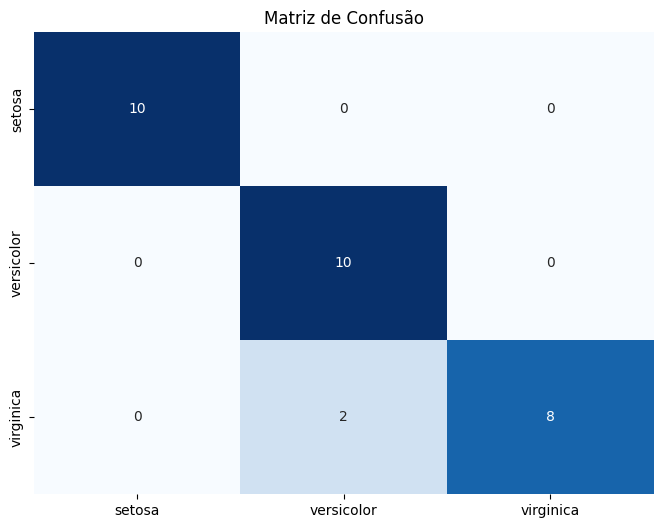

In [12]:
# Modelo de Regressão logística
logRegressor = LogisticRegression()
logRegressor.fit(train_f, train_t)
predictions = logRegressor.predict(test_f)

# Matriz de confusão
cm = confusion_matrix(test_t, predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title('Matriz de Confusão')
plt.show()

## Métricas à partir da Matriz de Confusão

* **Acurácia:** Total de previsões corretas em relação ao total;

* **Especificidade:** Total de verdadeiros negativos em relação ao total de reais negativos;

* **Precisão:** Total de verdadeiros positivos em relação ao total de previsões positivas (todos os positivos previstos pelo modelo, mesmo que tenha errado);

* **Recall:** Total de verdadeiro positivo em relação aos reais positivos (reais positivos + falsos negativos previstos pelo modelo).

* **F1-Score:** Média harmônica entre precisão e recall. Utilizada para conjunto de dados desbalanceados (muitos com aspecto X e poucos com Y). Da maior peso para os valores de categorias menores.

In [13]:
# O cálculo da precisão, recall e f1-score precisam de um parâmetro average='weighted' para calcular variáveis multiclasse

# Calculando a acurácia
print(f'Accuracy score: {accuracy_score(test_t, predictions):.2f}')

# Calculando a precisão
print(f'Precision score: {precision_score(test_t, predictions, average='weighted'):.2f}')

# Calculando o recall
print(f'Recall score: {recall_score(test_t, predictions, average='weighted'):.2f}')

# Calculando o f1-score
print(f'F1-Score: {f1_score(test_t, predictions, average='weighted'):.2f}')

Accuracy score: 0.93
Precision score: 0.94
Recall score: 0.93
F1-Score: 0.93


## ↪️ Curva Precision-Recall

Gráfico que mostra os valores de precision e recall para diferentes valores prováveis. O modelo ideial é: precision alto e recall alto.

**Trade-Off** é quando uma métrica aumenta, mas a outra diminui.
* **Aumento da precision:** modelo mais conservador
  * classifica menos elementos como positivo (menor recall)
  * menor chance de erro (maior precision)

* **Aumento do recall:** modelo mais agressivo
  * classifica mais exemplos como positivo (maior recall)
  * maior chance de erro (menor precision)

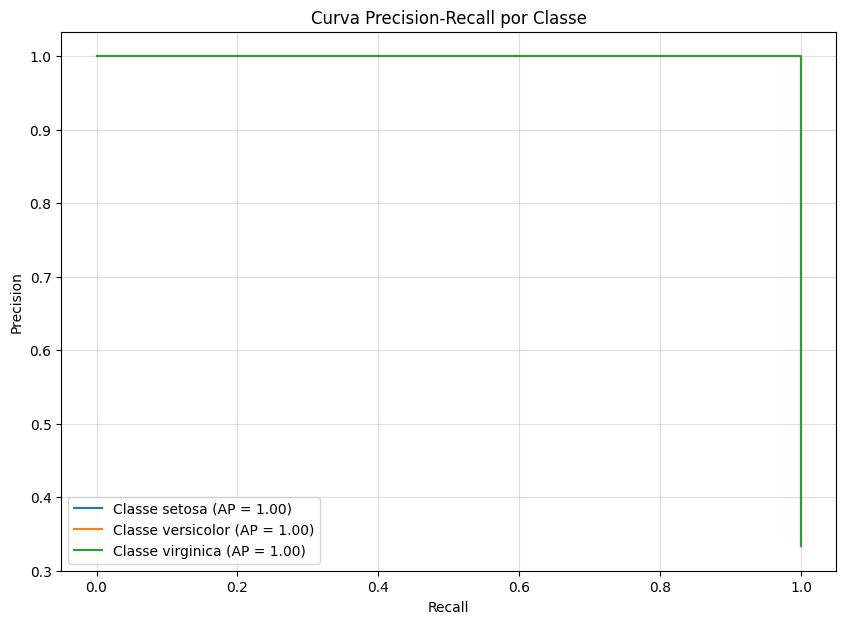

In [14]:
label_binarizer = LabelBinarizer()
y_true_binarized = label_binarizer.fit_transform(test_t)

n_classes = y_true_binarized.shape[1]

plt.figure(figsize=(10, 7))

for i in range(n_classes):
    y_score = logRegressor.predict_proba(test_f)[:, i]

    precision, recall, _ = precision_recall_curve(
        y_true_binarized[:, i], y_score
    )

    ap = average_precision_score(
        y_true_binarized[:, i], y_score
    )

    plt.plot(
        recall,
        precision,
        label=f'Classe {iris.target_names[i]} (AP = {ap:.2f})'
    )

plt.title('Curva Precision-Recall por Classe')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(alpha=0.4)
plt.show()

## ↪️ Curva de ROC

Gráfico que mostra os valores de recall e taxa de falso negativo (inverso da espcificidade) para diferentes valores de limiares de decisão. Modelo ideal: alto recall e baixa taxa de falso negativo.

**Taxa de falso negativo** total de negativos classificados pelo modelo de forma incorreta.
* **Especificidade:** total de negativos classificados corretamente
* **Trade-Off:** O modelo tende a aleatoriedade quanto mais próximo de uma diagonal entre os pontos (1,1) e (0,0).

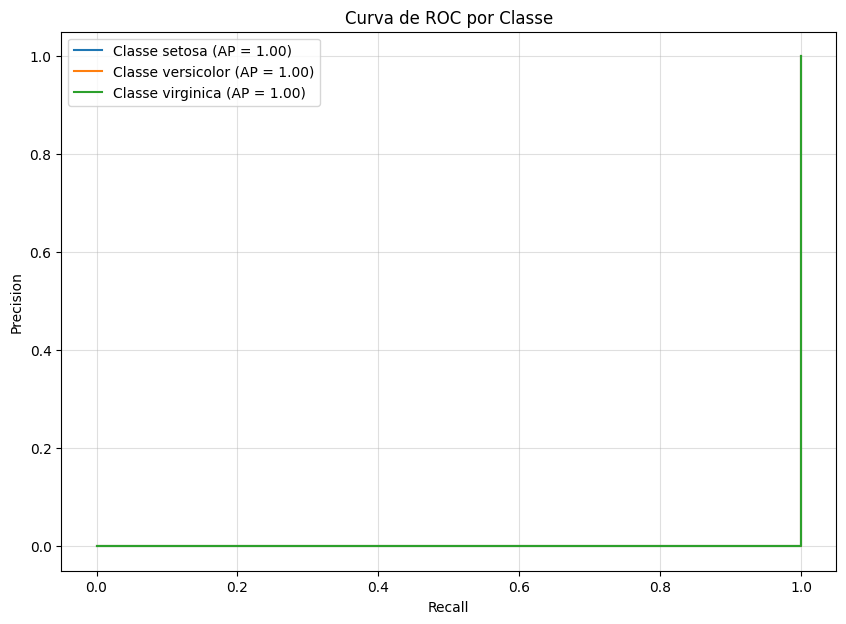

In [15]:
label_binarizer = LabelBinarizer()
y_true_binarized = label_binarizer.fit_transform(test_t)

n_classes = y_true_binarized.shape[1]

plt.figure(figsize=(10, 7))

for i in range(n_classes):
    y_score = logRegressor.predict_proba(test_f)[:, i]

    precision, recall, _ = roc_curve(
        y_true_binarized[:, i], y_score
    )

    ap = roc_auc_score(
        y_true_binarized[:, i], y_score
    )

    plt.plot(
        recall,
        precision,
        label=f'Classe {iris.target_names[i]} (AP = {ap:.2f})'
    )

plt.title('Curva de ROC por Classe')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(alpha=0.4)
plt.show()